In [1]:
!pip install -q gdown

In [2]:
import os
import gdown

if not os.path.exists("best_model.pth"):
    file_id = "165Cmqc59LIpecBwBVVk7p3Mmw_HiZfz-"
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, "best_model.pth", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=165Cmqc59LIpecBwBVVk7p3Mmw_HiZfz-
From (redirected): https://drive.google.com/uc?id=165Cmqc59LIpecBwBVVk7p3Mmw_HiZfz-&confirm=t&uuid=651cc416-590d-4833-90e5-cd848dd594e7
To: /content/best_model.pth
100%|██████████| 94.4M/94.4M [00:02<00:00, 45.1MB/s]


In [3]:
!pip install opencv-python-headless albumentations grad-cam -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
for param in model.parameters():
    param.requires_grad = False

In [13]:
model.fc = nn.Linear(model.fc.in_features, 5)

print(model.fc)

Linear(in_features=2048, out_features=5, bias=True)


In [15]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [16]:
from torch.utils.data import Dataset
from PIL import Image
import os

class RetinaDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_name = self.df.loc[idx, "id_code"] + ".png"

        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        label = int(self.df.loc[idx, "diagnosis"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [20]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

In [21]:
TRAIN_MODEL = False

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

if TRAIN_MODEL:

    num_epochs = 5

    best_val_loss = float("inf")

    for epoch in range(num_epochs):

        # Training
        model.train()

        train_loss = 0

        for batch_idx, (images, labels) in enumerate(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

            if (batch_idx + 1) % 20 == 0:
                print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()

        val_loss = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"\nEpoch {epoch+1} Completed")
        print(f"Training Loss : {avg_train_loss:.4f}")
        print(f"Validation Loss : {avg_val_loss:.4f}")

        # Save Best Model
        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss

            torch.save(
                model.state_dict(),
                "/content/drive/MyDrive/RetinaScanAI_edwin/best_model.pth"
            )

            print("Best model saved!\n")

else:
    print("Training skipped. Using the pretrained model.")

Training skipped. Using the pretrained model.


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

import numpy as np

In [24]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
import os
import gdown

if not os.path.exists("best_model.pth"):
    file_id = "165Cmqc59LIpecBwBVVk7p3Mmw_HiZfz-"
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, "best_model.pth", quiet=False)

model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)

model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [27]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Sample Images

Example retinal images are available in the GitHub repository:

https://github.com/edwinmanojmathew/RetinaScanAI/tree/main/sample_images

Download any image from that folder and upload it below, or use your own retinal image.

Saving fcc6aa6755e6.png to fcc6aa6755e6.png


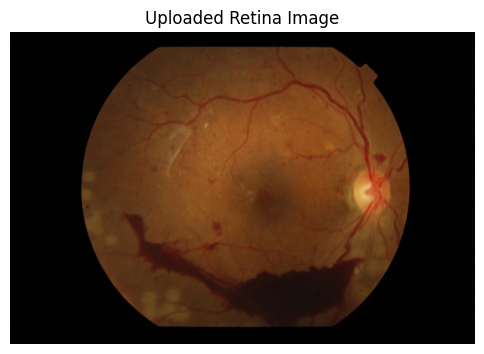

In [31]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Uploaded Retina Image")
plt.axis("off")
plt.show()

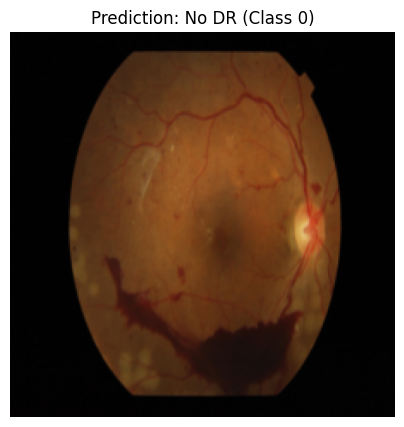

In [32]:
display_transform = transforms.Compose([
    transforms.Resize((224,224))
])

display_image = display_transform(image)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

input_tensor = transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

plt.figure(figsize=(5,5))
plt.imshow(display_image)
plt.title(f"Prediction: {class_names[predicted_class]} (Class {predicted_class})")
plt.axis("off")
plt.show()

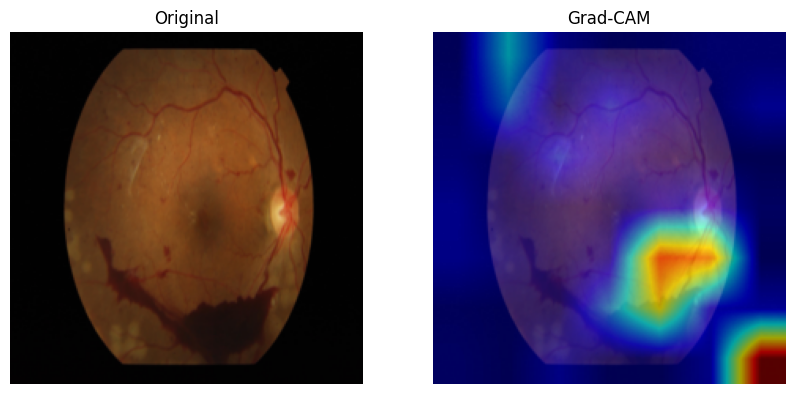

In [33]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

rgb_img = np.array(display_image).astype(np.float32) / 255.0

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

model.eval()
model.zero_grad()

input_tensor = input_tensor.clone().detach().requires_grad_(True)

with torch.enable_grad():
    output = model(input_tensor)
    target_category = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(target_category)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

grayscale_cam = cv2.resize(
    grayscale_cam,
    (rgb_img.shape[1], rgb_img.shape[0])
)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()